## **Logistic Regresison**

- Scenario 1, using generated synthetic data (numpy)
- Scenario 2, using real world data

#### **Load Libraries**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.api as sm 

## **Scenario 1**

#### **Generate Data**

In [33]:
np.random.seed(42) # enables reproducability
n = 200 # dataset size 
score = np.random.uniform(0,10,n) # predictor
log_odds = -4 + 0.8*score # linear log odds y = mx+c
prob = 1 / (1 + np.exp(-log_odds)) # inverse of the logit
y = np.random.binomial(1, prob, n) # binary outcome 
df = pd.DataFrame({'score':score, 'y':y}) # convert into a dataframe

In [34]:
df

,score,y
0,3.745401,0
1,9.507143,1
2,7.319939,1
3,5.986585,0
4,1.560186,0
...,...,...
195,3.492096,1
196,7.259557,1
197,8.971103,1
198,8.870864,1


#### **Instantiate & fit the model**

In [21]:
X = sm.add_constant(df['score'])
model = sm.Logit(df['y'], X).fit() 

Optimization terminated successfully.
         Current function value: 0.355712
         Iterations 7


In [22]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1998
Method:                           MLE   Df Model:                            1
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4867
Time:                        21:16:16   Log-Likelihood:                -711.42
converged:                       True   LL-Null:                       -1386.1
Covariance Type:            nonrobust   LLR p-value:                2.197e-295
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4041      0.195    -22.561      0.000      -4.787      -4.021
score          0.8662      0.036     24.157      0.000       0.796       0.936
==============================================================================
"""

In [40]:
beta0 = model.params['const']
beta1 = model.params['score']
odds_ratio = np.exp(beta1)

print(f"Intercept (beta0): {beta0:.3f}")
print(f"Coefficient for score (beta1): {beta1:.3f}")
print(f"Odds Ratio for score: {odds_ratio:.3f}")

# Optional: 95% CI for the odds ratio
conf = model.conf_int()
conf['OR'] = np.exp(conf)
print("\n95% CI for Odds Ratio:\n", conf[['OR', 0, 1]])

Intercept (beta0): -4.404
Coefficient for score (beta1): 0.866
Odds Ratio for score: 2.378


ValueError: Cannot set a DataFrame with multiple columns to the single column OR

#### **Evaluation**

In [38]:
# Predict probablities for a range of values
score_range = np.linspace(0,10,100) # range of values
X_pred = sm.add_constant(score_range)
pred_probs = model.predict(X_pred)

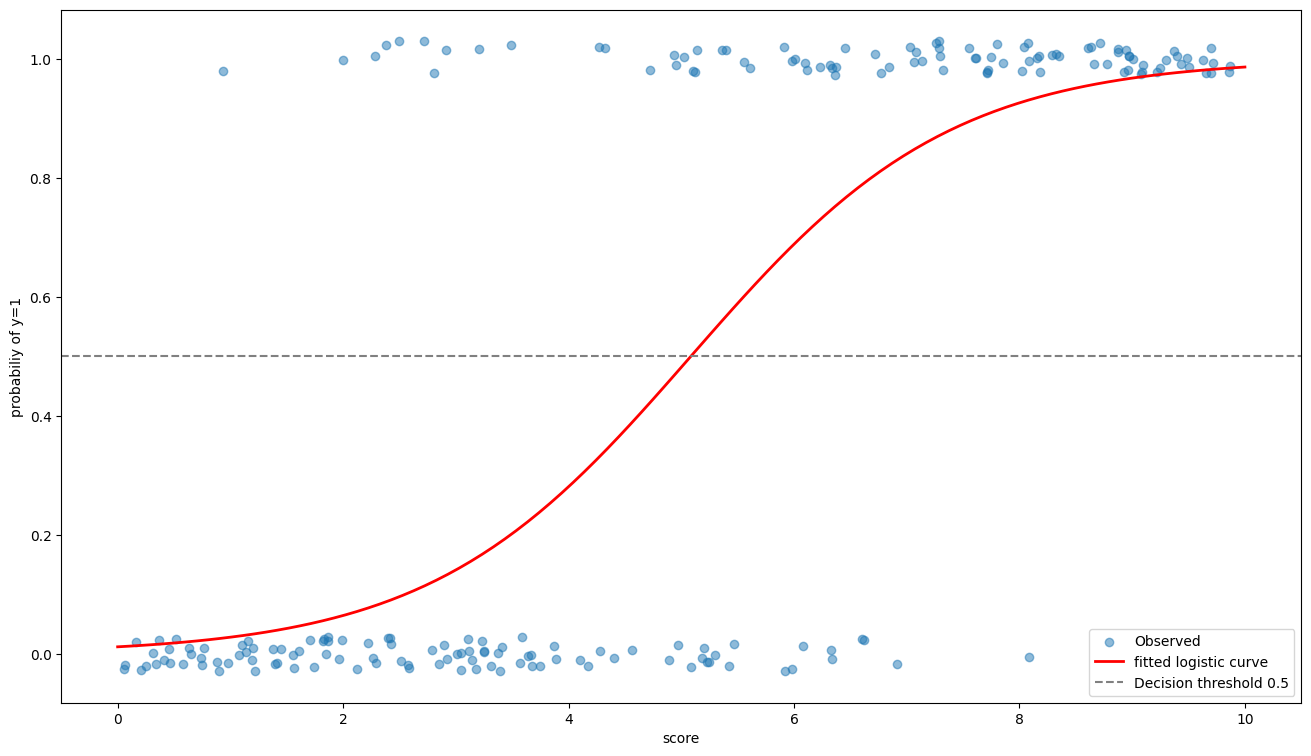

In [39]:
# scatter plot : 

plt.figure(figsize=(16,9))
plt.scatter(df['score'], df['y'] + np.random.uniform(-0.03, 0.03, n), alpha=0.5, label="Observed")
plt.plot(score_range, pred_probs, 'r-', lw=2, label='fitted logistic curve')
plt.axhline(0.5, color='grey',linestyle='--', label='Decision threshold 0.5')
plt.xlabel('score')
plt.ylabel('probabiliy of y=1')
plt.legend()
plt.show()


<hr>

**Resources:**
- [Elicit Research ](https://elicit.com/find-papers/f0c83851-8458-42eb-b61d-8d8de4de89c6)
- [ML-Book](https://christophm.github.io/interpretable-ml-book/logistic.html)
- [LogisticRregresison NotebookLM instance](https://notebooklm.google.com/notebook/e74d81b1-64d5-4088-a1ba-8bbaa2811795)

<hr>